# ChestMNIST

Radiografia de tórax, 14 achados por imagem. Multi-label: os achados coexistem.

Consome `results/`. Não produz artefato.

In [1]:
RAIZ <- "../../results/_smoke"
DATASET <- "medmnist-chestmnist-28"

suppressMessages(devtools::load_all("../../analysis", quiet = TRUE))
suppressMessages({ library(ggplot2); library(dplyr) })
options(repr.plot.width = 9, repr.plot.height = 4.5)

eda <- read_dataset_eda(DATASET, RAIZ)
s <- eda$summary

## Dimensões

In [2]:
data.frame(
  campo = c("classes", "canais", "resolução", "treino", "validação", "teste"),
  valor = c(s$num_classes, s$in_channels, paste(s$resolution, collapse = "x"),
            s$n_examples$train, s$n_examples$val, s$n_examples$test)
)

campo,valor
<chr>,<chr>
classes,14
canais,1
resolução,28x28
treino,78468
validação,11219
teste,22433


## Prevalência por achado

Multi-label não tem distribuição de classes. Tem prevalência por rótulo, e a
soma passa de 100%.

In [3]:
prev <- tibble::enframe(unlist(s$label_prevalence$train), "achado", "prevalencia") |>
  arrange(desc(prevalencia))
prev |> mutate(prevalencia = sprintf("%.2f%%", 100 * prevalencia)) |> as.data.frame()

achado,prevalencia
<chr>,<chr>
infiltration,17.73%
effusion,11.80%
atelectasis,10.19%
nodule,5.58%
mass,5.08%
pneumothorax,4.72%
consolidation,4.16%
pleural,2.90%
cardiomegaly,2.49%


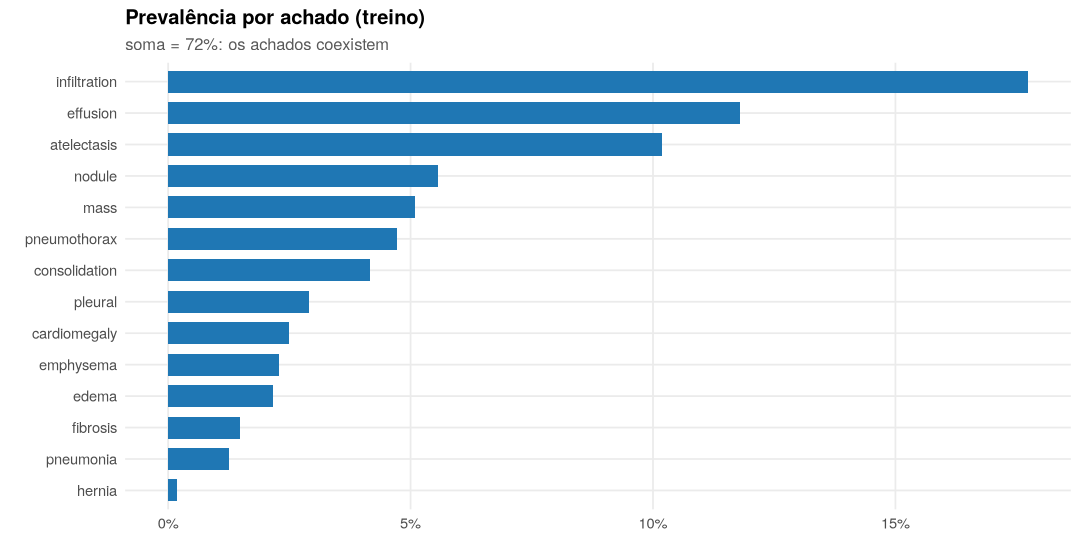

In [4]:
ggplot(prev, aes(x = reorder(achado, prevalencia), y = prevalencia)) +
  geom_col(fill = "#1f77b4", width = 0.7) +
  coord_flip() +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
  labs(title = "Prevalência por achado (treino)",
       subtitle = sprintf("soma = %.0f%%: os achados coexistem", 100 * sum(prev$prevalencia)),
       x = NULL, y = NULL) +
  theme_cvlab()

In [5]:
cat(sprintf("mais prevalente: %s (%.2f%%)\n", prev$achado[1], 100 * prev$prevalencia[1]))
cat(sprintf("mais raro:       %s (%.2f%%)\n", prev$achado[nrow(prev)], 100 * prev$prevalencia[nrow(prev)]))
cat(sprintf("razão:           %.0fx\n", prev$prevalencia[1] / prev$prevalencia[nrow(prev)]))

mais prevalente: infiltration (17.73%)


mais raro:       hernia (0.18%)


razão:           97x


Prevalência de 0,18% no achado mais raro significa que um classificador que
sempre responde "ausente" acerta 99,82% naquele rótulo. Acurácia é inútil aqui.
A métrica do benchmark oficial é AUC por rótulo.

## Achados por imagem

In [6]:
fpe <- tibble::enframe(unlist(s$findings_per_example$train), "n_achados", "n") |>
  mutate(n_achados = as.integer(n_achados), p = n / sum(n))
fpe |> mutate(p = sprintf("%.1f%%", 100 * p)) |> as.data.frame()

n_achados,n,p
<int>,<int>,<chr>
0,42405,54.0%
1,21602,27.5%
2,9970,12.7%
3,3378,4.3%
4,829,1.1%
5,218,0.3%
6,49,0.1%
7,14,0.0%
8,1,0.0%


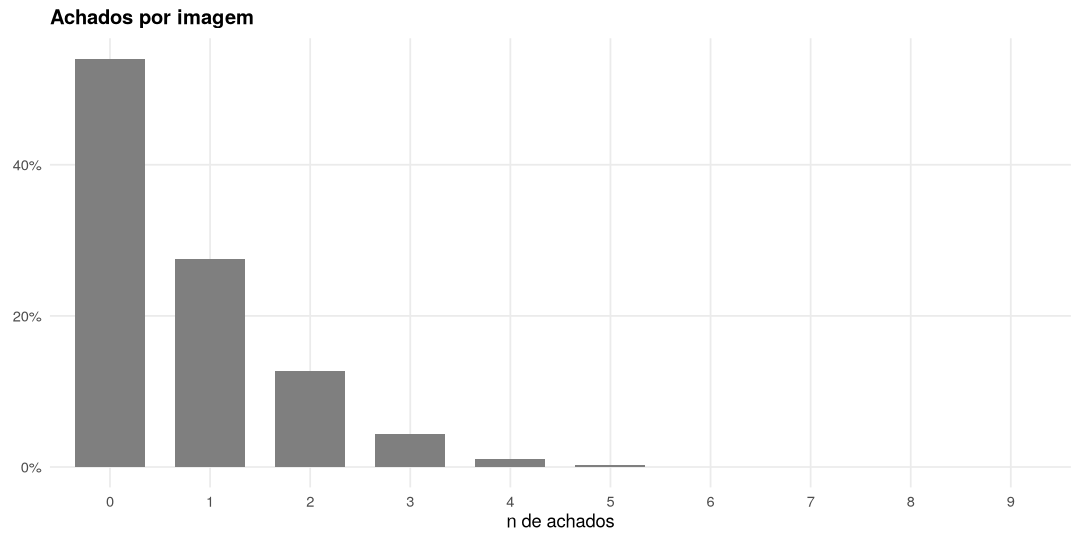

In [7]:
ggplot(fpe, aes(x = factor(n_achados), y = p)) +
  geom_col(fill = "#7f7f7f", width = 0.7) +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
  labs(title = "Achados por imagem", x = "n de achados", y = NULL) +
  theme_cvlab()

In [8]:
cat(sprintf("sem nenhum achado: %.1f%%\n", 100 * fpe$p[fpe$n_achados == 0]))
cat(sprintf("com 2 ou mais:     %.1f%%\n", 100 * sum(fpe$p[fpe$n_achados >= 2])))

sem nenhum achado: 54.0%


com 2 ou mais:     18.4%


A maioria das imagens é normal. Isso define o piso: prever "nada" acerta a
maior parte do dataset sem aprender nada.

## As imagens

Uma grade por achado. Uma mesma radiografia aparece em vários painéis quando tem
mais de um achado.

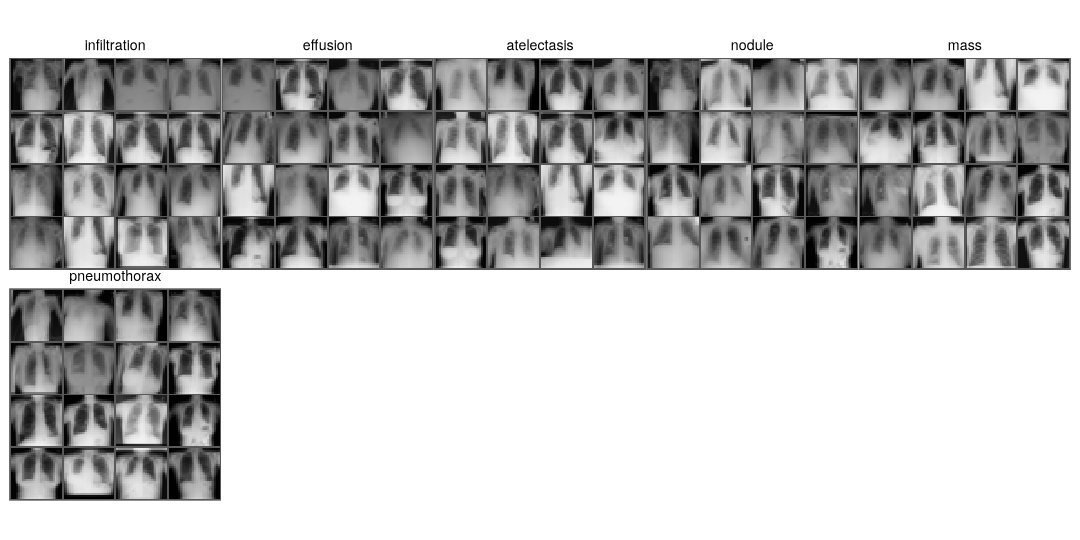

In [9]:
montage_grid(eda, classes = prev$achado[1:6], root = RAIZ)

## Estatística de pixel

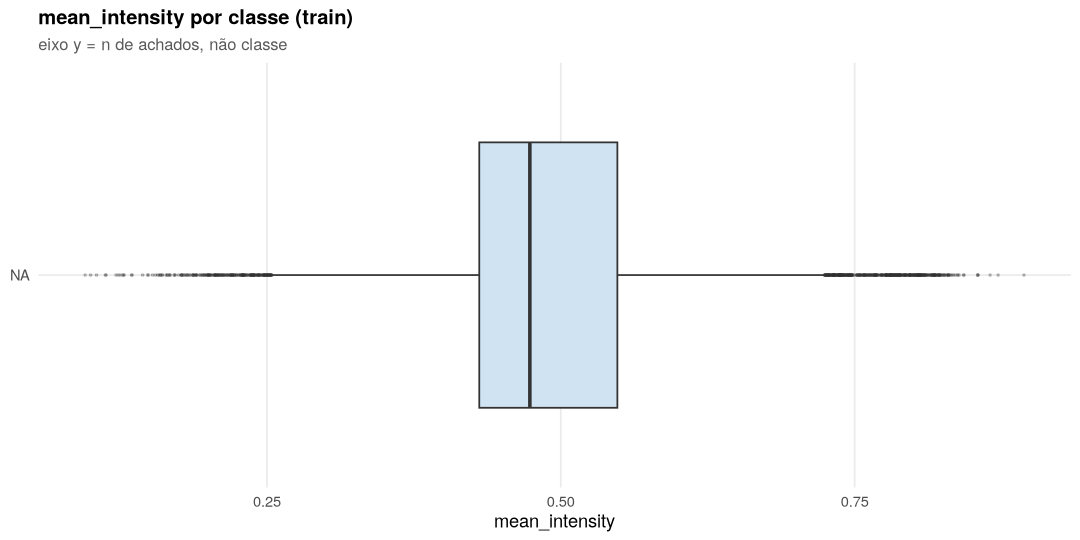

In [10]:
plot_feature_by_class(eda, "mean_intensity", "train") + labs(subtitle = "eixo y = n de achados, não classe")

In [11]:
treino <- filter(eda$examples, split == "train")
r2 <- sapply(c("mean_intensity", "std_intensity", "nonzero_frac"), function(v)
  summary(lm(as.formula(paste(v, "~ factor(y_true)")), data = treino))$r.squared)
round(r2, 4)

mean_intensity  std_intensity   nonzero_frac 
        0.0101         0.0008         0.0005

`y_true` aqui é a contagem de achados, não uma classe. R² próximo de zero: o
número de achados não é predizível por estatística global de pixel.

## Comparabilidade entre splits

In [12]:
eda$examples |>
  group_by(split) |>
  summarise(n = n(), across(c(mean_intensity, std_intensity, nonzero_frac), mean), .groups = "drop") |>
  as.data.frame()

split,n,mean_intensity,std_intensity,nonzero_frac
<chr>,<int>,<dbl>,<dbl>,<dbl>
test,22433,0.4933883,0.2164940,0.9901483
train,78468,0.4936099,0.2169745,0.9894296
val,11219,0.4957371,0.2182934,0.9873291


## Consequências para o treino

- Loss: `BCEWithLogitsLoss`, uma decisão binária por rótulo.
- Métrica: AUC por rótulo, macro. Acurácia e balanced accuracy não se aplicam.
- Piso: prever "ausente" em tudo já acerta >99% em vários rótulos.